# Foraward simulation for sandbox

In [1]:
import os
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sleio import sle_io

## Frontend input

In [2]:
# simulation control
project_name = 'test_0710'
simulation_control = ('3D', 'steady', 'confined', 8)  # dimension, problem, aquifer, stress number

# Geometry control
dx = np.array( [43.5, 25, 20, 20, 20] + [7.5] * 19 + [6, 6, 5.5, 5.5, 6, 6] + [7.5] * 19 + [20, 20, 20, 25, 43.5])
dy = np.array( [31, 20, 20, 20, 10] + [7.5] * 24 + [10, 20, 20, 20, 31])
dz = np.array( [30, 25, 20, 15, 10, 10] + [5] * 11 + [7.5, 7.5] + [10, 10, 10, 25, 30, 35] )

start_coord = (0, 0, 0)         # origin coordinate (x0, y0, z0)
element_num = (54, 34, 25)      # element number in each direction (e_x, e_y, e_z)
element_spacing = (dx, dy, dz)  # element spacing in each direction (len(dx) = e_x-)

# initial condition
init_paras = (350, 0, 0.004, 0.00001, 0.4) # init_h, init_flux, init_K, init_Ss, porosity

# boundary condition
boundary = ('surface', 'UP', 'head')  # method, value, bc_type, bc_value

# injection well info
const_rate = 600
inj_time = (0, 600)
inj_1 = ((288.5, 71,  120), 'inj_1', {'rate':const_rate, 'time': inj_time})
inj_2 = ((88.5,  71,  110), 'inj_2', {'rate':const_rate, 'time': inj_time})
inj_3 = ((88.5,  191, 100), 'inj_3', {'rate':const_rate, 'time': inj_time})
inj_4 = ((88.5,  311, 90 ), 'inj_4', {'rate':const_rate, 'time': inj_time})
inj_5 = ((288.5, 311, 120), 'inj_5', {'rate':const_rate, 'time': inj_time})
inj_6 = ((488.5, 311, 110), 'inj_6', {'rate':const_rate, 'time': inj_time})
inj_7 = ((488.5, 191, 100), 'inj_7', {'rate':const_rate, 'time': inj_time})
inj_8 = ((488.5, 71,  90 ), 'inj_8', {'rate':const_rate, 'time': inj_time})

# observation well info
ob_1 = ((188.5, 71,  130), 'Pie_1')
ob_2 = ((88.5, 131,  200), 'Pie_2')
ob_3 = ((88.5, 251,  180), 'Pie_3')
ob_4 = ((188.5, 311, 150), 'Pie_4')
ob_5 = ((388.5, 311, 150), 'Pie_5')
ob_6 = ((488.5, 251, 180), 'Pie_6')
ob_7 = ((488.5, 131, 200), 'Pie_7')
ob_8 = ((388.5, 71,  130), 'Pie_8')

obs = [ob_1, ob_1, ob_3, ob_4, 
       ob_5, ob_6, ob_7, ob_8]

# time info for transient
flag = 'each_time_step'
dt, dt_max, dt_mul, t_max, max_red = (10, 10, 1, 600, 0)
time = (dt, dt_max, dt_mul, t_max, max_red, flag)      
                                
                                        

## Import sle_io package

In [3]:
test_forward = sle_io(project_name)

# Geometry 
test_forward.set_parameters(simulation_control)
test_forward.create_geometry(start_coord, element_num, element_spacing)
test_forward.create_initial(init_paras)
test_forward.create_boundary(boundary)

# events
test_forward.add_stress(1, time, obs, (inj_1,))
test_forward.add_stress(2, time, obs, (inj_2,))
test_forward.add_stress(3, time, obs, (inj_3,))
test_forward.add_stress(4, time, obs, (inj_4,))
test_forward.add_stress(5, time, obs, (inj_5,))
test_forward.add_stress(6, time, obs, (inj_6,))
test_forward.add_stress(7, time, obs, (inj_7,))
test_forward.add_stress(8, time, obs, (inj_8,))
test_forward.create_times()
test_forward.create_source()
test_forward.create_observation()

# simulation 
test_forward.create_function()
test_forward.create_simulation()
test_forward.create_problem()
test_forward.write_forward_input(path = 'test_folder')

Project: test_0710
Simulation in '3D' case, 'confined' aquifer under 'steady' state with 8 events
Ready for forward simulation!


## Run forward simulation

In [7]:
test_forward.run_forward(K = 0.008, Ss = 10**-5, print_output = True)

 DESKTOP-7H83G3D ranked            0  is alive
 3 -D model
 Start checking input files.
 No unreasonable values in input files. Start running VSAFT2.
 
 STEADY-STATE FLOW
 mainsb called
 done with mean head calculation
  stress            1  done.                                                    
                                                  
 STEADY-STATE FLOW
 mainsb called
 done with mean head calculation
  stress            2  done.                                                    
                                                  
 STEADY-STATE FLOW
 mainsb called
 done with mean head calculation
  stress            3  done.                                                    
                                                  
 STEADY-STATE FLOW
 mainsb called
 done with mean head calculation
  stress            4  done.                                                    
                                                  
 STEADY-STATE FLOW
 mainsb called
 done with mean he

## Plot simulation result

In [4]:
test_forward.read_stress_FwdObs('test_folder\O-FwdObs.dat', 350)

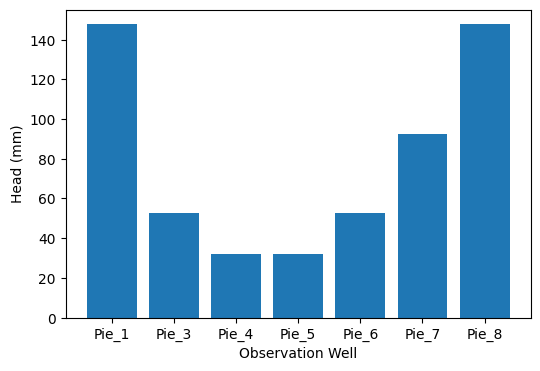

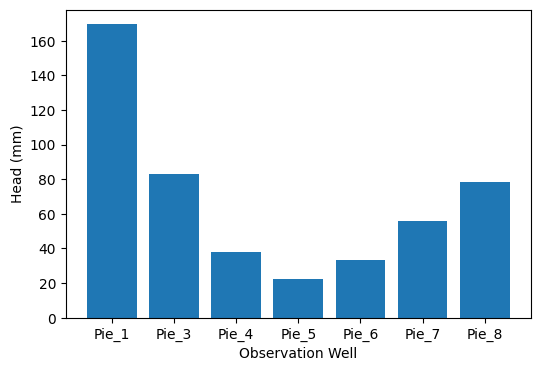

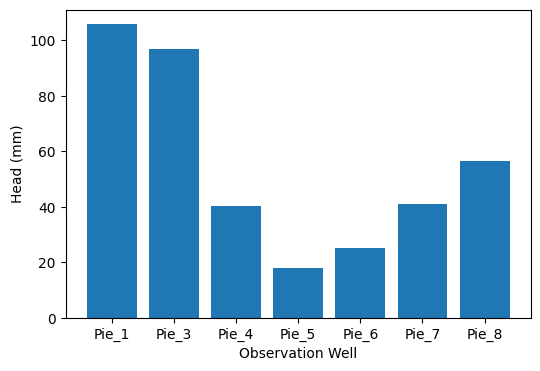

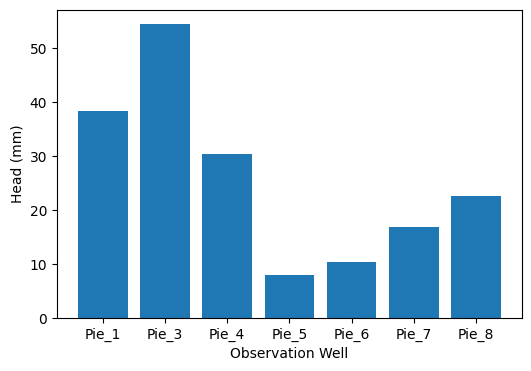

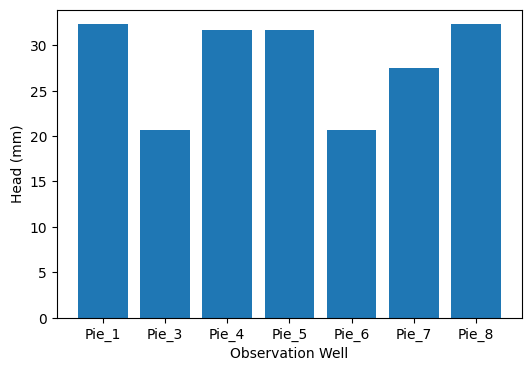

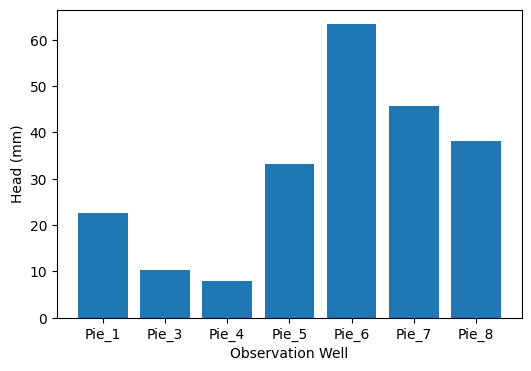

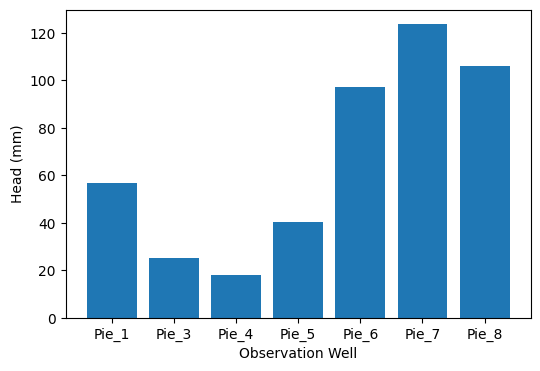

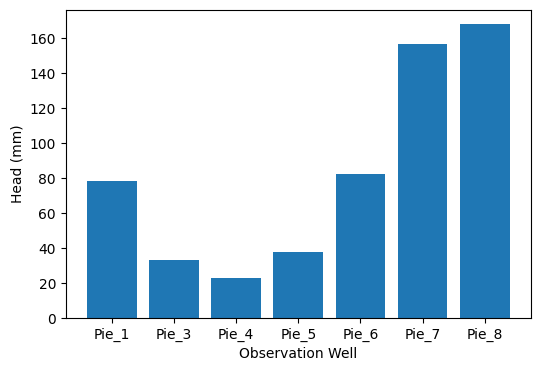

In [18]:
for i in range(test_forward.stress_number):
    
    df = test_forward.stress_result[f'stress_{i+1}']
    plt.figure(figsize=(6,4))
    plt.bar(df.columns, df.iloc[0])
    plt.xlabel("Observation Well")
    plt.ylabel("Head (mm)")
    plt.show()